<a href="https://colab.research.google.com/github/NoDanCoder/AirBnB_clone/blob/master/Semana5/CuadraturaGaussiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import sympy as sym

In [2]:
x = sym.Symbol('x',real='True')
F = sym.cos(x)**2
F

cos(x)**2

In [3]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [4]:
f = lambda x: np.cos(x)**2

In [5]:
W = np.array([1.,1.])
X = np.array([-1/np.sqrt(3),1/np.sqrt(3)])
I = np.sum(W*f(X))
I

np.float64(1.4041924619823274)

In [6]:
ROOTS,WEIGHTS = np.polynomial.legendre.leggauss(5)
ROOTS

array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985])

In [7]:
sum(ROOTS)

np.float64(0.0)

In [8]:
WEIGHTS

array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689])

In [9]:
sum(WEIGHTS)

np.float64(2.0)

In [10]:
I = np.sum(WEIGHTS*f(ROOTS))
I

np.float64(1.454649094168245)

In [11]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [12]:
sym.integrate(F,(x,0,sym.pi))

pi/2

In [13]:
a = 0
b = np.pi

In [14]:
I = 0.5*(b-a)*np.sum(WEIGHTS*f(0.5*(ROOTS*(b-a) + a + b)))
I

np.float64(1.5707479410586118)

In [15]:
# Necesitamos una familia de polinomios ortogonales en -1,1
def GetLegendre(n):

  x = sym.Symbol('x',Real=True)
  #y = sym.Symbol('y',Real=True)

  y = (x**2 - 1)**n

  poly = sym.diff(y,x,n)/(2**n * factorial(n))

  return poly

In [16]:
Legendre = GetLegendre(5)
Legendre

0.125*x*(8*x**4 + 40*x**2*(x**2 - 1) + 15*(x**2 - 1)**2)

In [17]:
x = sym.Symbol('x',Real=True)
DLegendre= sym.diff(Legendre,x,1)
DLegendre

1.0*x**4 + 5.0*x**2*(x**2 - 1) + 0.125*x*(112*x**3 + 140*x*(x**2 - 1)) + 1.875*(x**2 - 1)**2

In [18]:
LegendreNumpy  = sym.lambdify([x],Legendre,'numpy')
DLegendreNumpy = sym.lambdify([x],DLegendre,'numpy')

In [19]:
def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-14):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

In [20]:


def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-13):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

def GetAllRoots(f, df, x, tolerancia_decimales=8, tol_unicidad=1e-10):

    Roots = []

    for x0 in x:

        root = GetNewtonMethod(f, df, x0)

        if root is not False:

            # Redondeamos
            croot = np.round(root, tolerancia_decimales)

            # Verificamos que no esté ya (con tolerancia)
            if not any(np.isclose(croot, r, atol=tol_unicidad) for r in Roots):
                Roots.append(croot)

    Roots = np.array(Roots)
    Roots.sort()

    return Roots

In [21]:
x = sym.Symbol('x',Real=True)
F = sym.cos(10*x)*sym.exp(-0.9*x)
#F = x**3 - x**4 + 2*x**2 + 2*x + 1
F

exp(-0.9*x)*cos(10*x)

In [22]:
DF = sym.diff(F,x)
DF

-10*exp(-0.9*x)*sin(10*x) - 0.9*exp(-0.9*x)*cos(10*x)

In [23]:
# Funcion en numpy
Fn = sym.lambdify([x],F,'numpy')
DFn = sym.lambdify([x],DF,'numpy')

In [24]:
xi = np.linspace(-1,1,100,dtype=np.longdouble)
roots = GetAllRoots(LegendreNumpy,DLegendreNumpy,xi)
roots

array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985],
      dtype=float128)

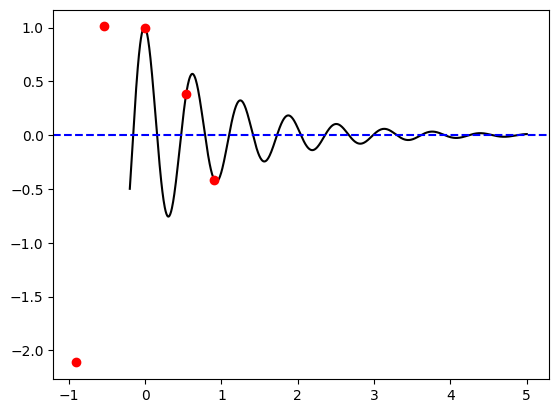

In [25]:
xj = np.linspace(-0.2,5,1000,dtype=np.longdouble)
plt.plot(xj,Fn(xj),color='k')
plt.plot(roots,Fn(roots),'o',color='r')
plt.axhline(0,linestyle='--',color='b')
#plt.xscale('log')

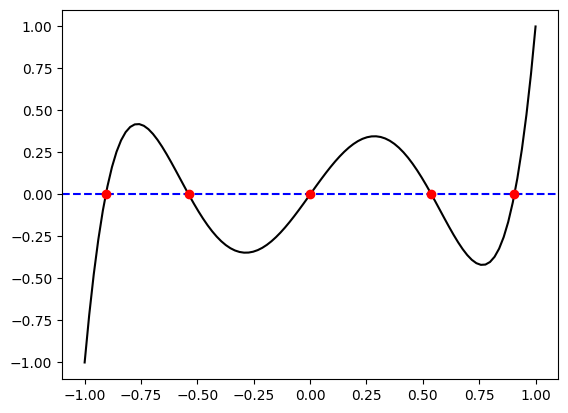

In [26]:
xj = np.linspace(-1,1,100,dtype=np.longdouble)
plt.plot(xj,LegendreNumpy(xj),color='k')
plt.axhline(0,linestyle='--',color='b')
plt.plot(roots,LegendreNumpy(roots),'o',color='r')

In [27]:
ROOTS

array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985])

In [28]:
weights = 2 / ( (1-ROOTS**2) * DLegendreNumpy(ROOTS)**2 )
weights

array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689])

In [29]:
WEIGHTS

array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689])

In [30]:
x = sym.Symbol('x',real='True')
y = sym.Symbol('y',real='True')
F = x**2 * sym.sin(x*y)
F

x**2*sin(x*y)

In [31]:
sym.integrate(F,(x,0,1.),(y,0,2.))

0.399387995723945

In [54]:
def f(x, y):
  return x**2 * np.sin(x*y)

In [85]:
def integral_doble(f, interval: tuple):
  a, b = interval[0]
  c, d = interval[1]

  xsi, wsi = np.polynomial.legendre.leggauss(15)
  xsj, wsj = np.polynomial.legendre.leggauss(15)

  return (b-a)*(d-c)*(1/4)*sum(wi * wj * f((1/2)*(xi*(b-a) + a + b), (1/2)*(xj*(d-c) + c + d)) for xi, wi in zip(xsi, wsi) for xj, wj in zip(xsj, wsj))


In [86]:
print(f'La integral doble de la funcion (x^2)sin(xy) es : {integral_doble(f, ((0,1),(0,2)))}')

La integral doble de la funcion (x^2)sin(xy) es : 0.3993879957239449
